# **1. Prebuilt Langgraph Supervisor 사용하기**

In [1]:
import getpass
import os


def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


_set_env("OPENAI_API_KEY")

OPENAI_API_KEY: ··········


In [2]:
!pip install langchain_openai langgraph_supervisor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.5 MB/s eta 0:00:00


In [3]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langgraph_supervisor import create_supervisor

In [4]:
model = ChatOpenAI(model="gpt-5.4-2026-03-05")

# tools
def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b

def multiply(a: float, b: float) -> float:
    """Multiply two numbers."""
    return a * b

def web_search(query: str) -> str:
    """Search the web for information."""
    return (
        "Here are the headcounts for each of the FAANG companies in 2024:\n"
        "1. **Facebook (Meta)**: 67,317 employees.\n"
        "2. **Apple**: 164,000 employees.\n"
        "3. **Amazon**: 1,551,000 employees.\n"
        "4. **Netflix**: 14,000 employees.\n"
        "5. **Google (Alphabet)**: 181,269 employees."
    )

# specialized agents
math_agent = create_agent(
    model=model,
    tools=[add, multiply],
    name="math_expert",
    system_prompt="You are a math expert. Always use one tool at a time."
)

research_agent = create_agent(
    model=model,
    tools=[web_search],
    name="research_expert",
    system_prompt="You are a world class researcher with access to web search. Do not do any math."
)

# supervisor workflow
workflow = create_supervisor(
    [research_agent, math_agent],
    model=model,
    prompt=(
        "You are a team supervisor managing a research expert and a math expert. "
        "For current events, use research_expert. "
        "For math problems, use math_expert."
    )
)

app = workflow.compile()

result = app.invoke({
    "messages": [
        {
            "role": "user",
            "content": "what's the combined headcount of the FAANG companies in 2024?"
        }
    ]
})

print(result)

{'messages': [HumanMessage(content="what's the combined headcount of the FAANG companies in 2024?", additional_kwargs={}, response_metadata={}, id='b0484458-c741-4549-8ec2-dff48e50210b'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 198, 'total_tokens': 215, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DSKvnVbp0ADyv6037AEr5kRjFWMvN', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, name='supervisor', id='lc_run--019d6cbf-fd63-7c20-afdb-073123d74b93-0', tool_calls=[{'name': 'transfer_to_research_expert', 'args': {}, 'id': 'call_I7tG8CoNCHdL6uK7fksc1rJt', 'type': 'tool_call'}], invalid_tool_calls=[], usage_

In [5]:
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

what's the combined headcount of the FAANG companies in 2024?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_research_expert (call_I7tG8CoNCHdL6uK7fksc1rJt)
 Call ID: call_I7tG8CoNCHdL6uK7fksc1rJt
  Args:
================================= Tool Message =================================
Name: transfer_to_research_expert

Successfully transferred to research_expert
================================== Ai Message ==================================
Name: research_expert

Using 2024 reported employee counts, the FAANG companies had a combined headcount of about **1.98 million employees**.

Breakdown:
- **Meta**: 67,317
- **Apple**: 164,000
- **Amazon**: 1,551,000
- **Netflix**: 14,000
- **Alphabet (Google)**: 181,269

Combined total:
- **1,977,586 employees**

If you want, I can also give you the same total using:
- fiscal year-end figur

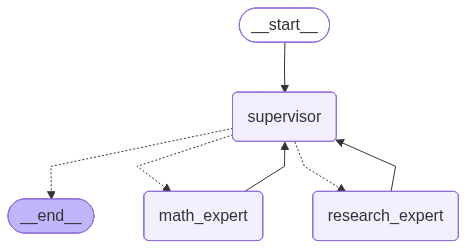

In [6]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

# **2. 자료 검색 전문 Agent 만들기**

In [8]:
_set_env("TAVILY_API_KEY")

TAVILY_API_KEY: ··········


In [9]:
!pip install langchain_community langchain_tavily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [10]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing import Annotated

In [11]:
llm = ChatOpenAI(model="gpt-5.4-2026-03-05", temperature=0)

search_tool = TavilySearch(max_results=5)

search_agent = create_agent(
    model=llm,
    tools=[search_tool],
    name="research_expert",
    system_prompt="You are a world class researcher with access to web search. Do not do any coding."
)

In [12]:
import io
import contextlib

In [13]:
@tool
def python_exec_tool(
    code: Annotated[str, "The python code to execute to generate your chart or anything."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        stdout_buffer = io.StringIO()
        with contextlib.redirect_stdout(stdout_buffer):
            exec(code)

        output = stdout_buffer.getvalue()

    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"

    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout:\n{output}"

    return result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."

In [14]:
from langchain.agents import create_agent

coding_agent = create_agent(
    model=llm,
    tools=[python_exec_tool],
    name="coding_expert",
    system_prompt="You can only generate python codes. Do not do any search.",
)

In [15]:
graph_builder = create_supervisor(
    [search_agent, coding_agent],
    model=llm,
    prompt=(
        "You are a team supervisor managing a research expert and a python coding expert. "
        "For current events, use research_agent. "
        "For coding problems, use coding_agent."
    )
)

graph = graph_builder.compile()

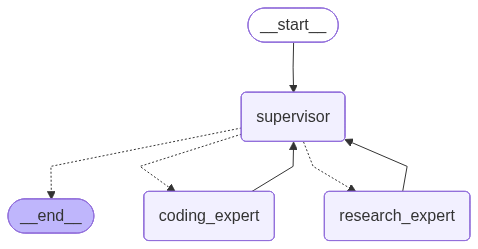

In [16]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [17]:
for node, chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "2025년 한강에서 열리는 행사에 대해 알려줘."
            }
        ]
    },
    subgraphs=True,
    stream_mode="updates",
):
    if(len(node) > 0):
        print("\n===== ", node, "=====")
    for state_key, state_value in chunk.items():
        print(f"State: {state_key}, Value: {state_value}")
        for msg in state_value["messages"]:
            msg.pretty_print()


=====  ('supervisor:85416041-9094-20fb-0426-ce37f6aacb24',) =====
State: agent, Value: {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 196, 'total_tokens': 213, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DSKwcrCdLpfHwGrsmtYDmR8jc4C0j', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, name='supervisor', id='lc_run--019d6cc0-c788-7c31-9211-d5220060d14d-0', tool_calls=[{'name': 'transfer_to_research_expert', 'args': {}, 'id': 'call_BnVPh9RGWRPQFX9mjto38vVP', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 196, 'output_tokens': 17, 'total_tokens': 213, 'input_token_

In [18]:
for node, chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "첫번째 항이 1인 피보나치 수열을 구하는 함수를 파이썬으로 작성해줘. 해당 함수의 10번째 항까지 출력해서 확인해줘."
            }
        ]
    },
    subgraphs=True,
    stream_mode="updates",
):
    if(len(node) > 0):
        print("\n===== ", node, "=====")
    for state_key, state_value in chunk.items():
        print(f"State: {state_key}, Value: {state_value}")
        for msg in state_value["messages"]:
            msg.pretty_print()


=====  ('supervisor:e9ce9bef-2d80-15c9-5394-2d989bfb4f16',) =====
State: agent, Value: {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 223, 'total_tokens': 240, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DSKxK4MUbEe0qdJfoSHnXw4mfGLvh', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, name='supervisor', id='lc_run--019d6cc1-7239-7281-a489-eb4879c6c25b-0', tool_calls=[{'name': 'transfer_to_coding_expert', 'args': {}, 'id': 'call_4gYhd2l8BPMO2BrVcCwss9eX', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 223, 'output_tokens': 17, 'total_tokens': 240, 'input_token_de


=====  ('supervisor:5101d7bf-7d78-5e81-84e8-327f716d43f5',) =====
State: agent, Value: {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 245, 'total_tokens': 262, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DSKxRFmkaavIJuxiCblffsw9lMuaG', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, name='supervisor', id='lc_run--019d6cc1-8f98-79c1-91c8-aec8452f96f2-0', tool_calls=[{'name': 'transfer_to_research_expert', 'args': {}, 'id': 'call_dFsokmLzsSQxBS9MzDrKWLlg', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 245, 'output_tokens': 17, 'total_tokens': 262, 'input_token_

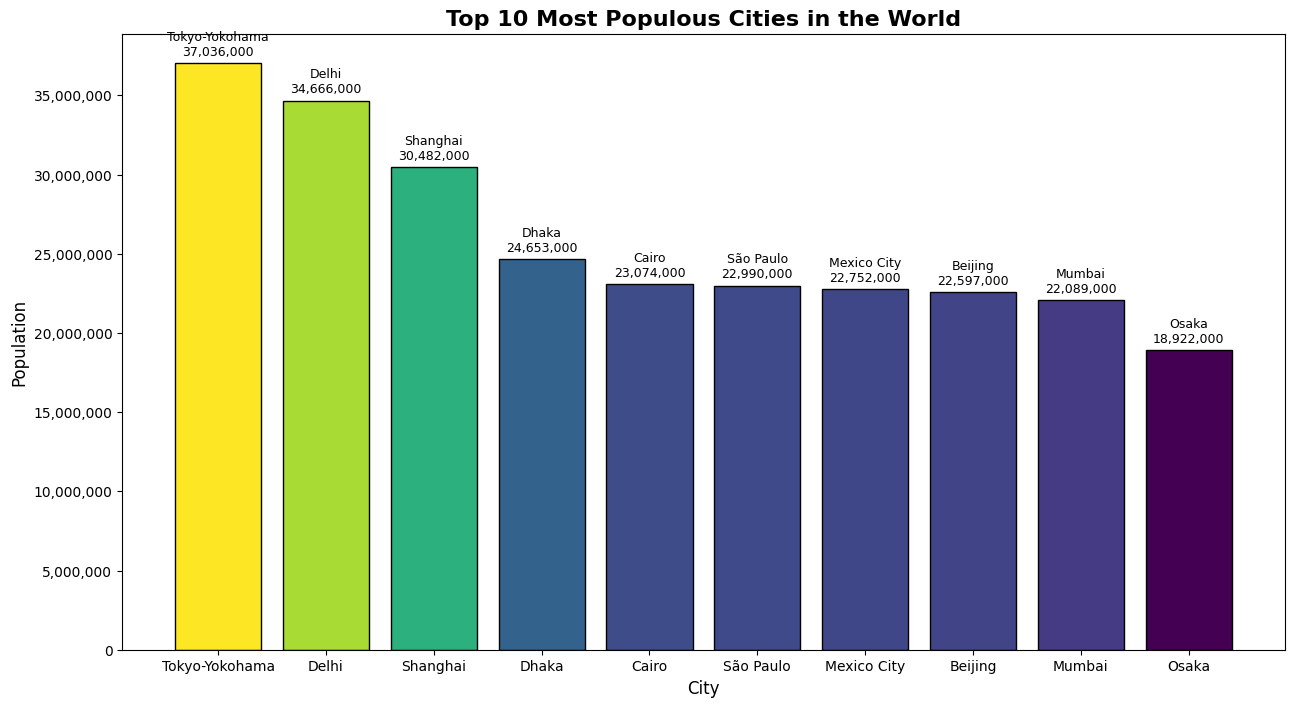

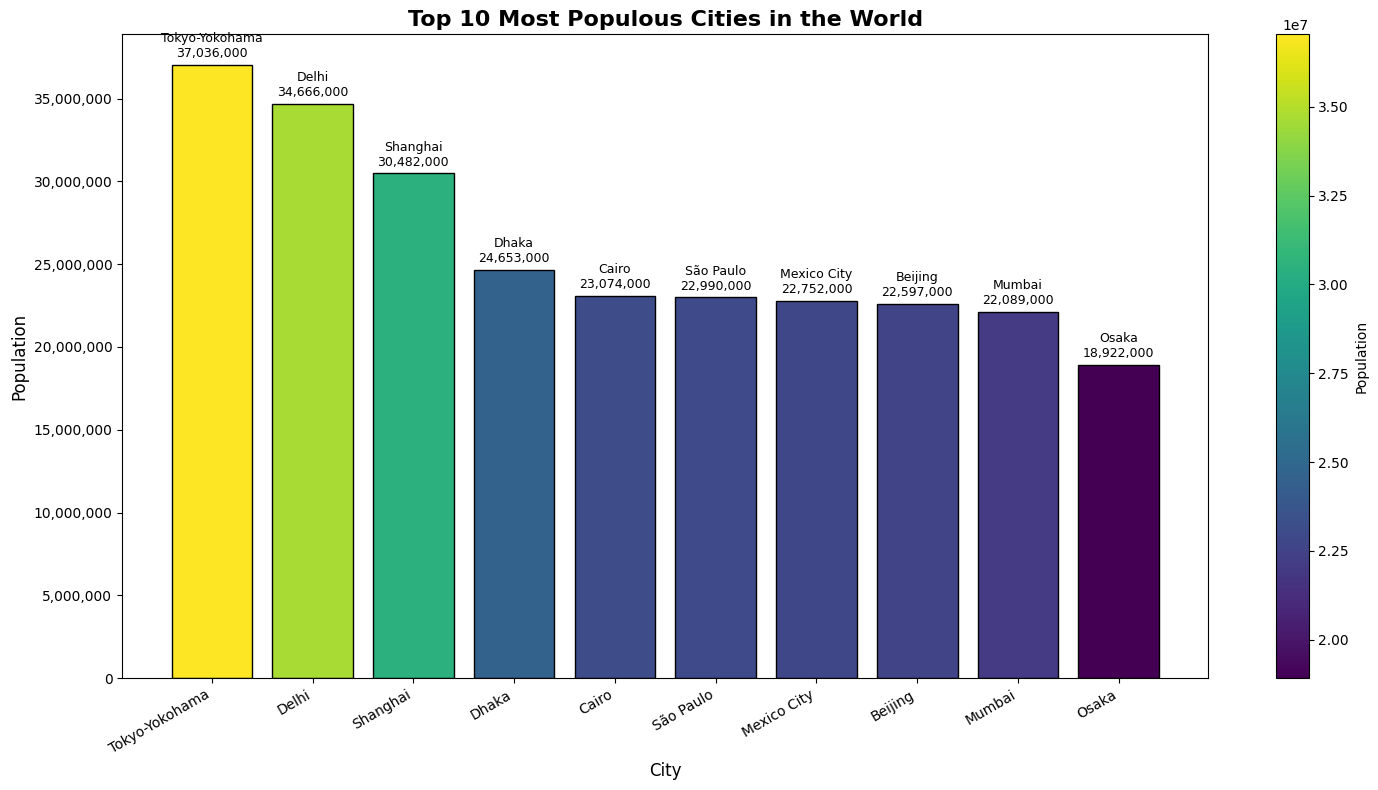


=====  ('coding_expert:348b2726-f72d-ebb1-903b-3f8f8f349dd6',) =====
State: tools, Value: {'messages': [ToolMessage(content='Successfully executed:\n```python\nimport matplotlib.pyplot as plt\nimport matplotlib as mpl\n\ncities = [\n    \'Tokyo-Yokohama\', \'Delhi\', \'Shanghai\', \'Dhaka\', \'Cairo\',\n    \'São Paulo\', \'Mexico City\', \'Beijing\', \'Mumbai\', \'Osaka\'\n]\npopulation = [\n    37036000, 34666000, 30482000, 24653000, 23074000,\n    22990000, 22752000, 22597000, 22089000, 18922000\n]\n\nnorm = mpl.colors.Normalize(vmin=min(population), vmax=max(population))\ncmap = plt.cm.viridis\ncolors = cmap(norm(population))\n\nfig, ax = plt.subplots(figsize=(15, 8))\nbars = ax.bar(cities, population, color=colors, edgecolor=\'black\')\n\nax.set_title(\'Top 10 Most Populous Cities in the World\', fontsize=16, weight=\'bold\')\nax.set_xlabel(\'City\', fontsize=12)\nax.set_ylabel(\'Population\', fontsize=12)\nax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, pos: f\'{

In [19]:
for node, chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": """세계에서 가장 인구가 많은 도시 10곳을 찾아, 도시별 인구수를 나타내는 시각화 코드를 실행해주세요. \n
            인구 수에 비례하여 막대 그래프의 색상을 설정하고, 각 도시의 이름과 인구수를 레이블로 추가해주세요.\n\n"""
            }
        ]
    },
    subgraphs=True,
    stream_mode="updates",
):
    if(len(node) > 0):
        print("\n===== ", node, "=====")
    for state_key, state_value in chunk.items():
        print(f"State: {state_key}, Value: {state_value}")
        for msg in state_value["messages"]:
            msg.pretty_print()